# Model Evaluation
In this notebook, we test our trained HMM on unseen data and compute evaluation metrics including Sensitivity, Specificity, and Accuracy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Redefine HMM class for prediction
class HMM:
    def __init__(self, n_states, n_symbols):
        self.n_states = n_states
        self.n_symbols = n_symbols
        self.pi = np.ones(n_states) / n_states
        self.A = np.ones((n_states, n_states)) / n_states
        self.B = np.ones((n_states, n_symbols)) / n_symbols
        
    def viterbi(self, obs):
        T = len(obs)
        delta = np.zeros((T, self.n_states))
        psi = np.zeros((T, self.n_states), dtype=int)
        
        delta[0] = np.log(self.pi + 1e-10) + np.log(self.B[:, obs[0]] + 1e-10)
        
        for t in range(1, T):
            for j in range(self.n_states):
                prob = delta[t-1] + np.log(self.A[:, j] + 1e-10)
                psi[t, j] = np.argmax(prob)
                delta[t, j] = np.max(prob) + np.log(self.B[j, obs[t]] + 1e-10)
                
        states = np.zeros(T, dtype=int)
        states[T-1] = np.argmax(delta[T-1])
        
        for t in range(T-2, -1, -1):
            states[t] = psi[t+1, states[t+1]]
            
        return states

hmm = HMM(4, 20)
params = np.load('hmm_params.npz')
hmm.pi = params['pi']
hmm.A = params['A']
hmm.B = params['B']

test_df = pd.read_csv('test_data.csv')

activities = ['standing', 'walking', 'jumping', 'still']


## Visualizing Model Parameters

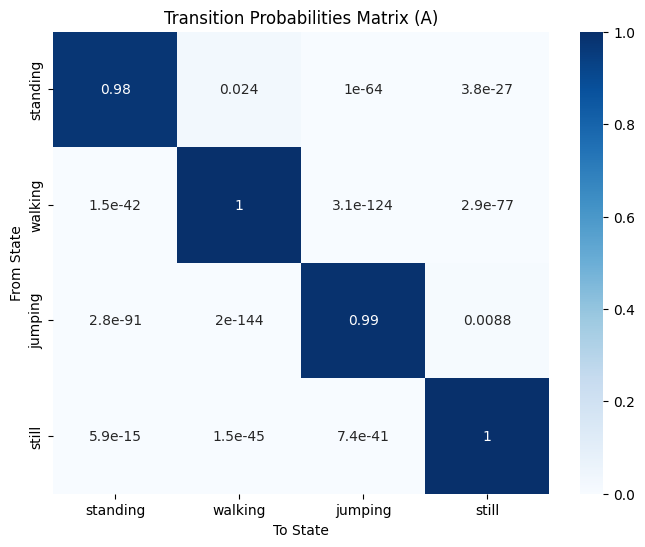

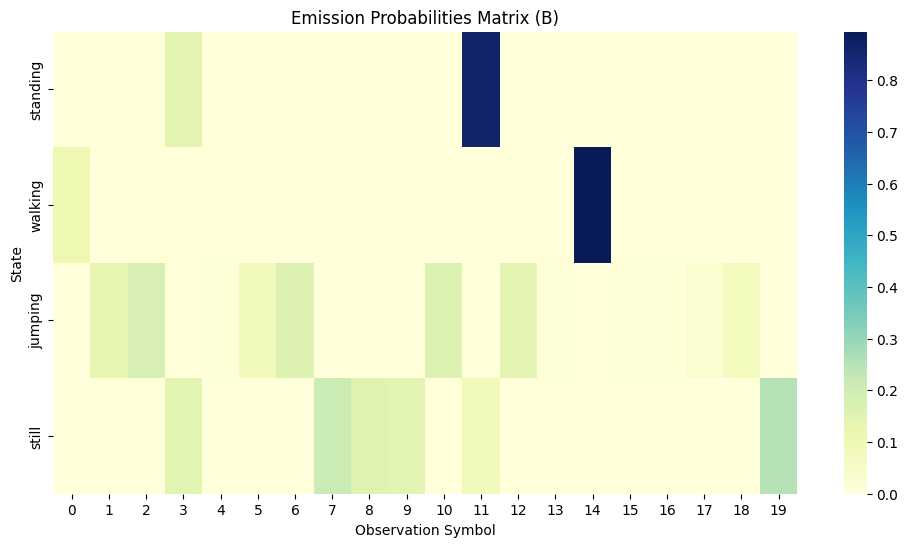

In [2]:
plt.figure(figsize=(8, 6))
sns.heatmap(hmm.A, annot=True, cmap='Blues', xticklabels=activities, yticklabels=activities)
plt.title('Transition Probabilities Matrix (A)')
plt.xlabel('To State')
plt.ylabel('From State')
plt.show()

plt.figure(figsize=(12, 6))
sns.heatmap(hmm.B, cmap='YlGnBu', yticklabels=activities)
plt.title('Emission Probabilities Matrix (B)')
plt.xlabel('Observation Symbol')
plt.ylabel('State')
plt.show()


## Evaluation on Unseen Data

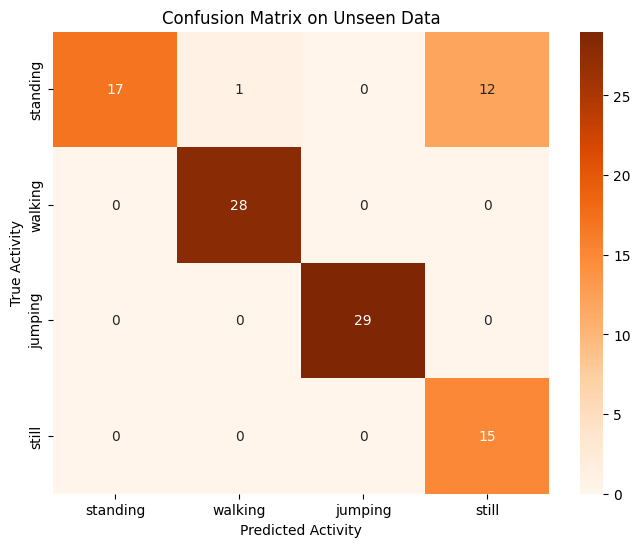

,State (Activity),Number of Samples,Sensitivity,Specificity,Overall Accuracy
0,standing,30,56.67%,100.00%,87.25%
1,walking,28,100.00%,98.65%,99.02%
2,jumping,29,100.00%,100.00%,100.00%
3,still,15,100.00%,86.21%,88.24%


In [3]:
y_true = []
y_pred = []

# Run Viterbi decoding for each session
for session, group in test_df.groupby('session'):
    obs = group['symbol'].values
    true_states = group['state'].values
    pred_states = hmm.viterbi(obs)
    
    y_true.extend(true_states)
    y_pred.extend(pred_states)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=activities, yticklabels=activities)
plt.title('Confusion Matrix on Unseen Data')
plt.xlabel('Predicted Activity')
plt.ylabel('True Activity')
plt.show()

# Calculate metrics
metrics = []
for i, act in enumerate(activities):
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - (tp + fn + fp)
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    acc = (tp + tn) / np.sum(cm) if np.sum(cm) > 0 else 0
    
    metrics.append({
        'State (Activity)': act,
        'Number of Samples': tp + fn,
        'Sensitivity': f"{sensitivity:.2%}",
        'Specificity': f"{specificity:.2%}",
        'Overall Accuracy': f"{acc:.2%}"
    })

metrics_df = pd.DataFrame(metrics)
display(metrics_df)
